# Clasificador paisajes
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás en el Classroom como `seg_train.zip` y `seg_test.zip`. Se pide:
1. Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones).

**NOTA apartado 1**: para el apartado 1 tendras que recorre las carpetas/imagenes con `os.listdir()`, e ir cargando todas las imagenes como arrays de numpy


In [22]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
import random
import os

In [23]:
IMAGE_WIDTH=32
IMAGE_HEIGHT=32
IMAGE_CHANNELS=3
IMAGE_SIZE=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)
BATCH_SIZE = 32
EPOCHS = 30

ROOT_PATH = 'C:\\Users\\Varushet\\Downloads\\clasificador_paisajes\\'

TRAIN_PATH = ROOT_PATH+ 'seg_train/'
TEST_PATH = ROOT_PATH + 'seg_test/'


CATEGORIES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [24]:
def cargar_datos(ruta, categorias):
    datos = []
    etiquetas = []
    
    for categoria in categorias:
        path_categoria = os.path.join(ruta, categoria)
        # Listar archivos en la carpeta de la categoría
        for img_nombre in os.listdir(path_categoria):
            try:
                # Construir ruta completa
                img_path = os.path.join(path_categoria, img_nombre)
                
                # Cargar imagen y redimensionar a 32x32
                img = load_img(img_path, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT))
                
                # Convertir a array numpy
                img_array = img_to_array(img)
                
                # Normalizar aquí mismo (dividir por 255) para tener datos entre 0 y 1
                # Esto cubre el apartado 3 también, pero es buena práctica hacerlo al cargar
                img_array = img_array / 255.0
                
                datos.append(img_array)
                etiquetas.append(categoria)
            except Exception as e:
                print(f"Error cargando {img_nombre}: {e}")
                
    return np.array(datos), np.array(etiquetas)

print("Cargando datos de entrenamiento...")
X_train_raw, y_train_raw = cargar_datos(TRAIN_PATH, CATEGORIES)
print(f"Datos de entrenamiento cargados: {X_train_raw.shape}")

print("Cargando datos de test...")
X_test_raw, y_test_raw = cargar_datos(TEST_PATH, CATEGORIES)
print(f"Datos de test cargados: {X_test_raw.shape}")

Cargando datos de entrenamiento...
Datos de entrenamiento cargados: (14034, 32, 32, 3)
Cargando datos de test...
Datos de test cargados: (3000, 32, 32, 3)


## 2. Investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.

Muestras del conjunto de entrenamiento:


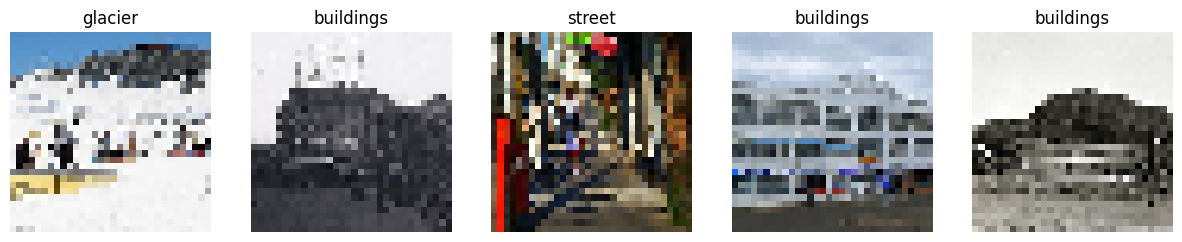

In [25]:
def mostrar_muestras(X, y, categorias, num_muestras=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_muestras):
        idx = random.randint(0, len(X) - 1)
        plt.subplot(1, num_muestras, i + 1)
        plt.imshow(X[idx])
        plt.title(y[idx])
        plt.axis('off')
    plt.show()

print("Muestras del conjunto de entrenamiento:")
mostrar_muestras(X_train_raw, y_train_raw, CATEGORIES)

## 3. Normaliza


In [26]:
X_train_raw = X_train_raw / 255.0
X_test_raw = X_test_raw / 255.0

print("Rango de valores píxel (debe ser 0 a 1):")
print(f"Min: {X_train_raw.min()}, Max: {X_train_raw.max()}")

Rango de valores píxel (debe ser 0 a 1):
Min: 0.0, Max: 0.003921568859368563


## 4. Diseña la arquitectura de la red. Recuerda que es un algoritmo de clasificación. Ojo con las dimensiones de la entrada

**NOTA apartado 4**: empieza con un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer. on softmax como ultima capa


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Codificar etiquetas
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_raw)
y_test_encoded = label_encoder.transform(y_test_raw)

# One-hot encoding para la capa de salida (softmax)
num_classes = len(CATEGORIES)
y_train_cat = to_categorical(y_train_encoded, num_classes)
y_test_cat = to_categorical(y_test_encoded, num_classes)

# Crear el modelo
model = Sequential([
    # Primera capa convolucional
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)),
    MaxPooling2D((2, 2)),
    
    # Segunda capa convolucional
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Capas Fully Connected
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Para evitar overfitting
    Dense(num_classes, activation='softmax') # Salida softmax para clasificación múltiple
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

c:\Users\Varushet\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,206 (1.20 MB)

 Trainable params: 315,206 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Reserva un 20% de los datos del entrenamiento para validar.


In [28]:
X_train, X_val, y_train, y_val = train_test_split(X_train_raw, y_train_cat, test_size=0.2, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Validación: {X_val.shape[0]} muestras")

Entrenamiento: 11227 muestras
Validación: 2807 muestras


In [29]:
history = model.fit(X_train, y_train,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(X_val, y_val))

Epoch 1/30


ValueError: Argument `output` must have rank (ndim) `target.ndim - 1`. Received: target.shape=(None, 6), output.shape=(None, 6)

## 6. Representa el objeto history


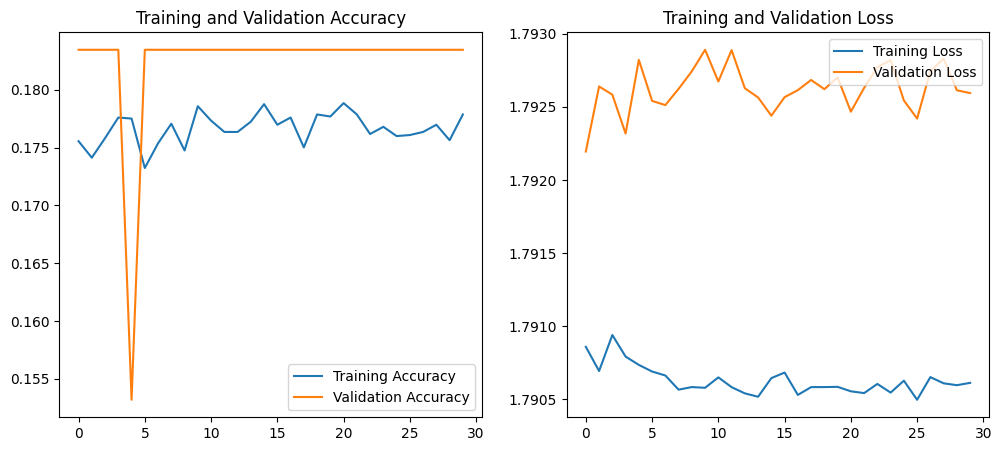

In [ ]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    epochs_range = range(len(acc))
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    
    plt.show()

plot_history(history)

## 7. Evalua el modelo con los datos de test


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_raw, y_test_cat)
print(f"Pérdida en Test: {test_loss:.4f}")
print(f"Precisión (Accuracy) en Test: {test_accuracy:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1750 - loss: 1.7901
Pérdida en Test: 1.7901
Precisión (Accuracy) en Test: 0.1750


## 8. Representa algunos de los paisajes donde el modelo comete errores


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


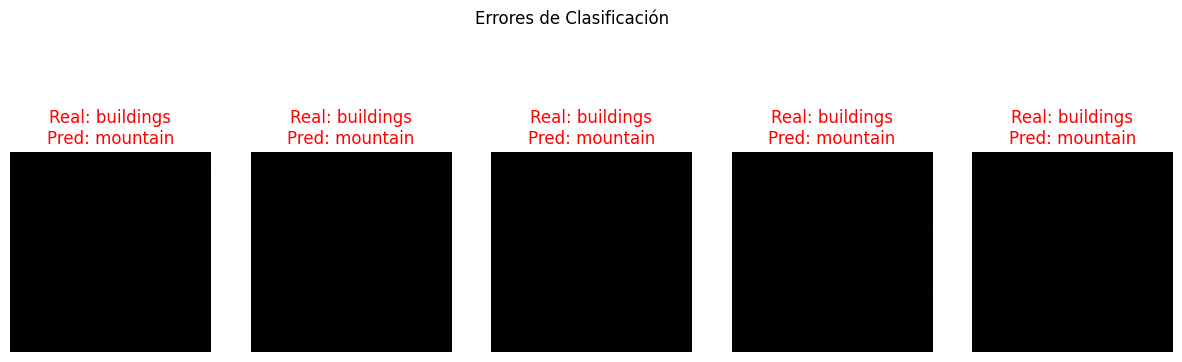

In [ ]:
# Obtener predicciones
y_pred_probs = model.predict(X_test_raw)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

# Encontrar índices donde hubo error
errores_idx = np.where(y_pred_classes != y_true_classes)[0]

plt.figure(figsize=(15, 5))
# Mostrar hasta 5 errores
num_mostrar = min(5, len(errores_idx))
for i in range(num_mostrar):
    idx = errores_idx[i]
    plt.subplot(1, num_mostrar, i + 1)
    plt.imshow(X_test_raw[idx])
    true_label = CATEGORIES[y_true_classes[idx]]
    pred_label = CATEGORIES[y_pred_classes[idx]]
    plt.title(f"Real: {true_label}\nPred: {pred_label}", color='red' if true_label != pred_label else 'green')
    plt.axis('off')
plt.suptitle("Errores de Clasificación")
plt.show()

## 9. Crea una matriz de confusión con los errores del modelo


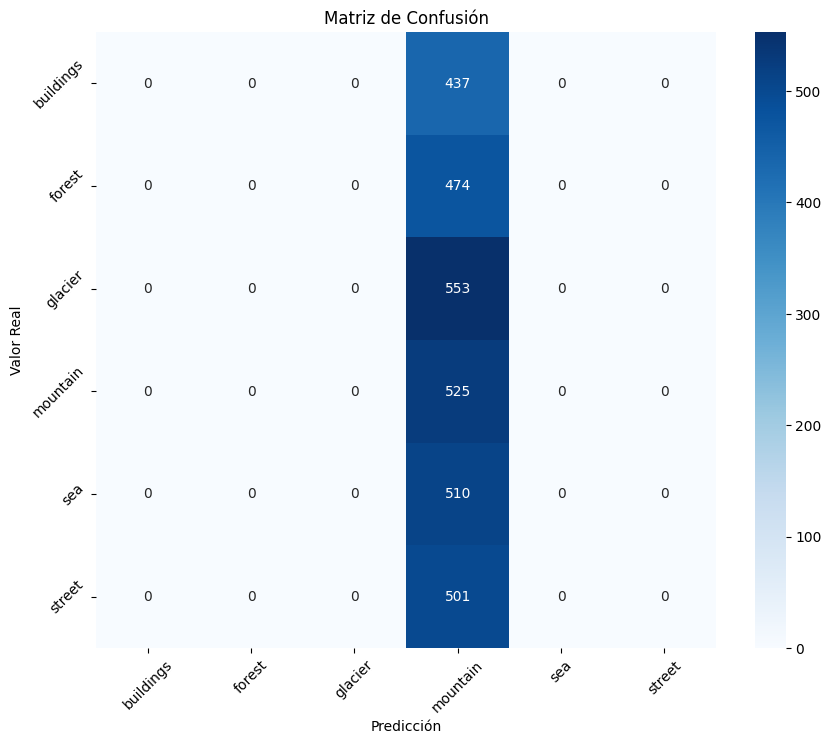

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()